<div style="background-color:#7BAFD4;border-radius:18px;padding:22px 26px;margin-bottom:18px;">
<div style="font-family:Impact,'Arial Black',Arial,sans-serif;font-size:42px;font-weight:900;letter-spacing:2px;line-height:1;color:white;">GEOG 592</div>
<div style="font-family:Arial,Helvetica,sans-serif;font-size:22px;font-weight:700;color:#13294B;margin-top:8px;">GIS Programming</div>
<div style="font-family:Arial,Helvetica,sans-serif;font-size:16px;color:#13294B;margin-top:6px;">GeoPandas — Spatial Relationships and Spatial Joins</div></div>
Asking spatial questions

This module will take us from measurement to relationships between features.

You will use the "spatial predicates" `within`, `contains`, `intersects`, along with Boolean spatial masks, and `gpd.sjoin()`.


In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
stops = gpd.read_file("data/chapel_hill_bus_stops.geojson")
parks = gpd.read_file("data/parks.geojson")
urban = gpd.read_file("data/urban_area.geojson")

## Visualize the layers

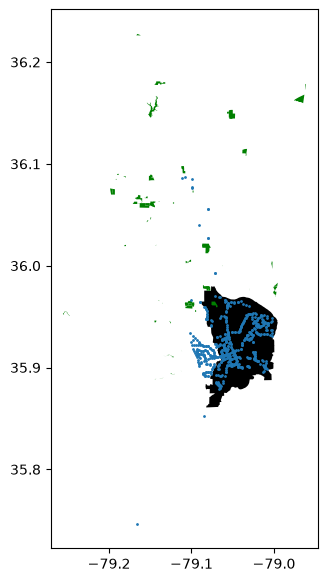

In [4]:
fig, ax = plt.subplots(figsize=(8,7))
urban.plot(ax=ax, color="black")
parks.plot(ax=ax, color="green")
stops.plot(ax=ax, markersize=1)
plt.show()

## What are spatial predicates?

Spatial predicates are spatial functions that return Boolean values. 

Some examples:

```python

within() ## "An object is said to be within other if at least one of its points is located in the interior and no points are located in the exterior of the other."

contains() ## "An object is said to contain other if at least one point of other lies in the interior and no points of other lie in the exterior of the object. (Therefore, any given polygon does not contain its own boundary - there is not any point that lies in the interior.)"
# Contains is the inverse of within 

intersects() ## "An object is said to intersect other if its boundary and interior intersects in any way with those of the other."
```


## Example using `within()`

In [5]:
len(urban)

1

In [6]:
# Select the first feature and make it a shapely geometry
urban_polygon = urban.geometry.iloc[0] 
# make a "within" spatial analysis 
inside_urban = stops.geometry.within(urban_polygon)

print(type(urban_polygon))
print(type(inside_urban))

<class 'shapely.geometry.polygon.Polygon'>
<class 'pandas.Series'>


In [7]:
stops[inside_urban].tail(3)

,OBJECTID,STOP_ID,STOP_ID2,NAME,DIR,ON_,AT,LAT,LONG,A,...,CAN_INSTAL,TRASH_PROB,TRASH_RECO,NEWSPAPER,NEWSPAPER_,BICYCLE,BIKE_SPACE,BIKE_PROBL,BIKE_RECOM,geometry
593,364,3423,3423,W Franklin St at University Baptist,E,W Franklin St,University,35.91270,-79.05675,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.05655 35.91275)
594,363,3422,3422,W Franklin St at Caribou Coffee,W,W Franklin St,Caribou Cof,35.91297,-79.05646,0,...,0,0,0,0,0,1,3,0,0,POINT (-79.05651 35.91297)
595,369,3428,3428,E Franklin St at Varsity Theatre,W,E Franklin St,Varsity The,35.91358,-79.05486,0,...,0,0,0,0,0,0,0,0,0,POINT (-79.05488 35.9136)


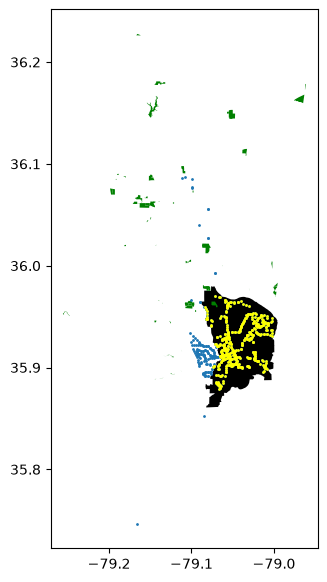

In [8]:
fig, ax = plt.subplots(figsize=(8,7))
urban.plot(ax=ax, color="black")
parks.plot(ax=ax, color="green")
stops.plot(ax=ax, markersize=1)
# inside_urban mask. 
stops[inside_urban].plot(ax=ax, markersize=1, c='yellow')
plt.show()

This selection of the `stops` inside the urban polygon uses the same syntax as a pandas selection:

```python
condition = ...
selected = data[condition]
```

The difference is that we are now using *spatial* conditions.


## Example using `contains` 

`contains()` and `within()` test the same relationship, but in different ways

In [ ]:
##  apply() here is like using a loop that applies urban.contains(park.geometry) on each park
## it returns a data frame
parks_within = parks.geometry.apply(urban.contains) 
parks[parks_within[0]] # get the first column to make a series we can use as a mask

#parks_within = parks.geometry.within(urban_polygon) ## using `within` creates a series directly
#parks[parks_within]

pandas.DataFrame

Two parks are inside the urban boundary. 
Can you think of how to print the just the names of those two parks? 

In [ ]:
## Names of the parks within Urban
parks[parks_within[0]]['NAME']
## parks_within is a df so [0] selects the column making it a series

## Intersects

In [10]:
park_intersect = parks.geometry.intersects(urban_polygon)
print(type(park_intersect))
parks[park_intersect]['NAME']

<class 'pandas.Series'>


26    Burlington Park (Town of Chapel Hill)
56              Headwater's Nature Preserve
Name: NAME, dtype: str

All three examples gave the same result.
Why?\
Different ways of asking the same question. 

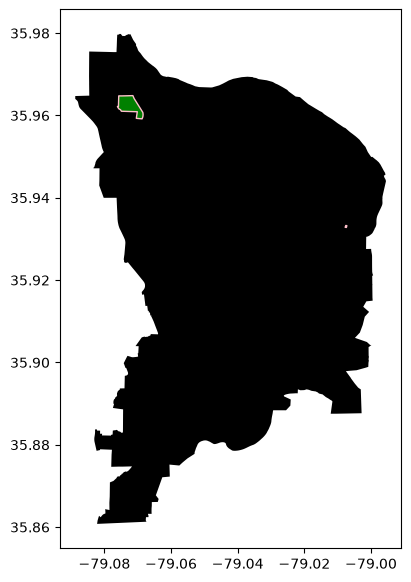

In [11]:
fig, ax = plt.subplots(figsize=(8,7))
urban.plot(ax=ax, color="black")
parks[park_intersect].plot(ax=ax, color="green", edgecolor='pink')
plt.show()

## Before the next section we will keep one or two columns to make it easier to read the table.  

In [12]:
print(parks.head(1))
print(urban.head(1))

   FID         AREA_  PERIMETER  PARCELS_  PARCELS_ID    CREATION   SIZE  \
0    1  439075.76317  3466.6519       625         624  09/21/2005  A10.1   

           OWNER         PIN     TMBL  ...                       NAME  \
0  ORANGE COUNTY  9950114431  2.5..9G  ...  Lewis' Heartleaf Preserve   

                    TYPE  CATEGORY_1      Acres  \
0  Parkland & open space  Open space  10.079793   

                                 GlobalID      Acquired  Year   Shape__Area  \
0  {F8631965-0D35-433C-8905-CDB60CEBD9DF}  1.127261e+12  2005  62811.214844   

   Shape__Length                                           geometry  
0    1309.388751  POLYGON ((-79.16178 36.22637, -79.16177 36.226...  

[1 rows x 23 columns]
   OBJECTID  URBANSER_  URBANSER_I          DATE   Shape__Area  Shape__Length  \
0         2          2           1  804470400000  7.150418e+08  158917.477493   

                                            geometry  
0  POLYGON ((-79.07451 35.87469, -79.07175 35.874...  


In [13]:
## From parks keep the FID, NAME and the geometry
parks = parks[['FID','NAME','geometry']]
## From urban keep the OBJECTID and the geometry
urban = urban[['OBJECTID','geometry']]
print(urban.head(1))
print(parks.head(1))


   OBJECTID                                           geometry
0         2  POLYGON ((-79.07451 35.87469, -79.07175 35.874...
   FID                       NAME  \
0    1  Lewis' Heartleaf Preserve   

                                            geometry  
0  POLYGON ((-79.16178 36.22637, -79.16177 36.226...  


## Spatial join

In [ ]:
# Joins the attribute data from urban (OBJECTID, geometry columns) 
# only to the parks objects that are within the urban polygon.
urban_parks = gpd.sjoin(parks, urban, predicate="within") ## this
print("the number of parks' features within urban:", len(urban_parks))

the number of parks' features within urban: 2


Let's look at columns inside the original gdfs and the output gdf. 

In [ ]:
print("Urban Parks Columns",urban_parks.columns)
print("Parks Columns",parks.columns)
# Shows which columns are added to urban parks by subtracting the columns that are in parks. 
newColumnsInUrbanParks = urban_parks.columns.difference(parks.columns)
print('These columns are in urban_parks and not in the parks:', newColumnsInUrbanParks)
print('Spatial join, adds columns to the dataset!')

Urban Parks Columns Index(['FID', 'NAME', 'geometry', 'index_right', 'OBJECTID'], dtype='str')
Parks Columns Index(['FID', 'NAME', 'geometry'], dtype='str')
These columns are in urban_parks and not in the parks: Index(['OBJECTID', 'index_right'], dtype='str')
Spatial join, adds columns to the dataset!


## Notice that spatial join keeps only the features that are within; however, other methods exist. 

From https://geopandas.org/en/latest/docs/reference/api/geopandas.sjoin.html#

Available predicates include:

    'intersects': True if geometries intersect (boundaries and interiors)

    'within': True if left geometry is completely within right geometry

    'contains': True if left geometry completely contains right geometry

    'contains_properly': True if left geometry contains right geometry and their boundaries do not touch

    'overlaps': True if geometries overlap but neither contains the other

    'crosses': True if geometries cross (interiors intersect but neither contains the other, with intersection dimension less than max dimension)

    'touches': True if geometries touch at boundaries but interiors don’t

    'covers': True if left geometry covers right geometry (every point of right is a point of left)

    'covered_by': True if left geometry is covered by right geometry

    'dwithin': True if geometries are within specified distance (requires distance parameter)


### You can retain all the features from your `left` or `right` dataset if you wish by changing the `how` parameter. 

For the previous example the left gdf is `parks` and the right one is `urban`. 



In [17]:
## in this example, again parks is on the left and urban is on the right
# Urban is joined to parks. 
urban_parks = gpd.sjoin(parks, urban, how = 'left', predicate="within") ## this
print("the number of features is:", len(urban_parks))
print(urban_parks.head())

the number of features is: 68
   FID                                NAME  \
0    1           Lewis' Heartleaf Preserve   
1    2  Cedar Grove Park (additional land)   
2    3          Little River Regional Park   
3    4          Little River Regional Park   
4    5                         Lake Orange   

                                            geometry  index_right  OBJECTID  
0  POLYGON ((-79.16178 36.22637, -79.16177 36.226...          NaN       NaN  
1  POLYGON ((-79.13185 36.18019, -79.13185 36.180...          NaN       NaN  
2  POLYGON ((-78.96214 36.1786, -78.9615 36.17818...          NaN       NaN  
3  POLYGON ((-78.96311 36.16803, -78.96458 36.159...          NaN       NaN  
4  POLYGON ((-79.14132 36.16565, -79.14105 36.165...          NaN       NaN  


Notice that the new gdf (urban_parks) kept all the features from the left gdf (parks), and it gained the columns OBJECTID and index_right from the urban gdf. 

However the only parks' features that should have an OBJECTID value should be the same two that we saw earlier. 

In [16]:
urban_parks[urban_parks["OBJECTID"].notna()]

,FID,NAME,geometry,index_right,OBJECTID
26,27,Burlington Park (Town of Chapel Hill),"POLYGON ((-79.00723 35.93323, -79.00737 35.932...",0,2
56,57,Headwater's Nature Preserve,"POLYGON ((-79.07569 35.96476, -79.07483 35.964...",0,2


If you remember the first assessment, an attribute join matches records using a shared field. A spatial join matches records using location. 

> We have not done attibute joins yet using Pandas or GeoPandas. In Pandas and Geopandas, attibute joins are called merge. 

## Let's see some attribute joins with mock data

### First we will create a population DF with no geometry

In [18]:
import pandas as pd
from shapely.geometry import Point

population = pd.DataFrame({
    "name": ["A", "B", "C"],
    "population": [1000, 2000, 1500]
})

population

,name,population
0,A,1000
1,B,2000
2,C,1500


### Now we will create a set of points representing cities 

In [ ]:
cities = gpd.GeoDataFrame(
    {
        "name": ["A", "B", "D"],
        "geometry": [
            Point(2, 4),
            Point(3, 6),
            Point(4, 2)
        ]
    },
    crs="EPSG:3857"
)

cities

In [ ]:
### Notice that the gdf has geometry but no information about population. Also notice that we did not create a point C

In [ ]:
### Now let's make a join

In [ ]:
cities_population = cities.merge(
    population,
    on="name", # this is the join field 
    how="left" # means that the cities will retain the information
)

cities_population

## Creating a proportional symbol map

In [ ]:
import matplotlib.pyplot as plt

# function to assign size to the points 
## This function is the only part that I really want you to understand
def symbol_size(series, scale):
    series = series/scale
    series[series.isna()] = scale * 2
    return series


fig, ax = plt.subplots(figsize=(7, 7))

cities_population.plot(
    ax=ax,
    markersize= symbol_size(cities_population["population"],5),
    color="orange",
    edgecolor="green",
    alpha=0.7
)

for x, y, name, population in zip( ## loop created using AI
    cities_population.geometry.x,
    cities_population.geometry.y,
    cities_population["name"],
    cities_population["population"]
):
    ax.annotate(
        f"City {name}\nPopulation: {population:,.0f}",
        xy=(x, y),
        xytext=(x + 0.7, y + 0.7),
        arrowprops={"arrowstyle": "-", "color": "black"},
        bbox={
            "boxstyle": "round,pad=0.3",
            "facecolor": "white",
            "edgecolor": "black"
        },
        fontsize=9
    )

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xticks(range(0, 11))
ax.set_yticks(range(0, 11))
ax.set_aspect("equal")
ax.grid(True)
ax.set_title("City Proportional Symbol")


plt.show()

## Making a choropleth 

In [ ]:

# function to assign size to the points 
def symbol_size(series, scale):
    size_series = series/scale
    size_series[size_series.isna()] = scale * 2
    return size_series

## This next function is the only part that I really want you to understand
def symbol_color(series):
    color_series = pd.Series("black", index=series.index) # another way of making a series of the same size. 
    color_series.loc[series.between(500, 1500, inclusive="right")] = "cyan"
    color_series.loc[series > 1500] = "blue"
    color_series.loc[series.isna()] = "red"
    return color_series

fig, ax = plt.subplots(figsize=(7, 7))

cities_population.plot(
    ax=ax,
    markersize= symbol_size(cities_population["population"],5),
    color = symbol_color(cities_population["population"]),
    alpha=0.7
)

for x, y, name, population in zip( ## loop created using AI
    cities_population.geometry.x,
    cities_population.geometry.y,
    cities_population["name"],
    cities_population["population"]
):
    ax.annotate(
        f"City {name}\nPopulation: {population:,.0f}",
        xy=(x, y),
        xytext=(x + 0.7, y + 0.7),
        arrowprops={"arrowstyle": "-", "color": "black"},
        bbox={
            "boxstyle": "round,pad=0.3",
            "facecolor": "white",
            "edgecolor": "black"
        },
        fontsize=9
    )

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xticks(range(0, 11))
ax.set_yticks(range(0, 11))
ax.set_aspect("equal")
ax.grid(True)
ax.set_axisbelow(True)
ax.set_title("City Proportional Symbol / Choropleth")

plt.show()

One final thought: 

Buffer is a super useful and simple method. 
Let's apply it to our mock data. 

In [ ]:
cities_population.buffer(10)

In [ ]:
fig, ax = plt.subplots(figsize=(8,7))
cities_population.buffer(1).plot(ax=ax, color="black", alpha=0.7)
cities_population.plot(ax=ax, color="green", edgecolor='pink')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xticks(range(0, 11))
ax.set_yticks(range(0, 11))
ax.set_aspect("equal")
ax.grid(True)
ax.set_axisbelow(True)
ax.set_title("Buffers")
plt.show()


In [ ]:
title = 'Variable Distance Buffers based on Population'
fig, ax = plt.subplots(figsize=(8,7))
cities_population.buffer(cities_population['population']/1000).plot(ax=ax, color="black", alpha=0.7)
cities_population.plot(ax=ax, color="green", edgecolor='pink')
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xticks(range(0, 11))
ax.set_yticks(range(0, 11))
ax.set_aspect("equal")
ax.grid(True)
ax.set_axisbelow(True)
ax.set_title(title)
plt.show()
